In [10]:
# =============================================================
# ERA COMPARISON PROJECT - Notebook 4: Era 3 Deep Learning
#
# Era 3 Philosophy: Instead of hand-crafted features (Era 2),
# let the model learn its own representations directly from
# raw sequential data.
#
# Key shift from Era 2:
# - Era 2: We decide which features matter (RSI, MA ratios...)
# - Era 3: Model learns what to look for by itself
#
# Algorithm: Transformer with Self-Attention
# - Originally designed for language (powers ChatGPT)
# - Adapted here for financial time series
# - Core idea: find relationships between ANY two points
#   in a sequence, no matter how far apart they are
#
# Input: last 60 days of price returns
# Output: predicted return for tomorrow
# Signal: if predicted return > 0, buy (1); else stay out (0)
# =============================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

ticker = 'AAPL'
data = yf.download(ticker, start='2014-01-01', end='2024-01-01')
prices = data['Close'].squeeze()
dates = data.index

print(f"Total trading days: {len(prices)}")

[*********************100%***********************]  1 of 1 completed

Total trading days: 2516


In [11]:
# =============================================================
# DATA PREPARATION
#
# Why returns instead of raw prices?
# Raw prices have a critical flaw: the model can "cheat" by
# learning that tomorrow's price ≈ today's price.
# This produces near-zero loss but zero trading value.
# We discovered this trap in our first attempt and fixed it
# by switching to returns (daily % changes).
#
# This is a real and common mistake in financial ML -
# known as the "naive prediction trap."
#
# Why normalize to [0,1]?
# Neural networks are sensitive to the scale of input data.
# A return of +0.02 and -0.15 need to be on the same scale
# for the model to learn effectively.
# We save the scaler to reverse the transformation later.
# =============================================================

# Compute daily returns instead of using raw prices
# pct_change() = (today - yesterday) / yesterday
returns = prices.pct_change().dropna().values

# Scale returns to [0,1] range for neural network training
# fit_transform learns the min/max from data and applies scaling
scaler = MinMaxScaler()
returns_scaled = scaler.fit_transform(returns.reshape(-1, 1)).flatten()

# Parameters
SEQ_LEN = 60    # use last 60 days to predict next day
PRED_LEN = 1    # predict 1 day ahead
SPLIT = 0.8     # 80% train, 20% test

split_idx = int(len(returns_scaled) * SPLIT)
train_data = returns_scaled[:split_idx]
test_data = returns_scaled[split_idx - SEQ_LEN:]  # overlap for continuity

print(f"Training days: {split_idx}")
print(f"Test days: {len(returns_scaled) - split_idx}")

Training days: 2012
Test days: 503


In [12]:
# =============================================================
# DATASET CLASS
#
# We slice the returns sequence into overlapping windows.
# Each window = one training example.
#
# Example with SEQ_LEN=4 for simplicity:
# returns = [r1, r2, r3, r4, r5, r6, r7...]
#
# Window 1: input=[r1,r2,r3,r4], target=r5
# Window 2: input=[r2,r3,r4,r5], target=r6
# Window 3: input=[r3,r4,r5,r6], target=r7
#
# This gives us many training examples from one sequence.
# With SEQ_LEN=60 and ~2000 days, we get ~1940 training windows.
# =============================================================

class TimeSeriesDataset(Dataset):
    """
    Converts a 1D time series into (input_sequence, target) pairs.
    Inherits from PyTorch Dataset for compatibility with DataLoader.
    """
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        # Total number of windows we can create
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # Input: seq_len consecutive returns
        x = self.data[idx : idx + self.seq_len]
        # Target: the next pred_len returns we want to predict
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        # unsqueeze(-1) adds a feature dimension: (seq_len,) -> (seq_len, 1)
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor(y)

train_dataset = TimeSeriesDataset(train_data, SEQ_LEN, PRED_LEN)
test_dataset = TimeSeriesDataset(test_data, SEQ_LEN, PRED_LEN)

# DataLoader batches examples together for efficient training
# shuffle=True for training (randomizes order to prevent pattern memorization)
# shuffle=False for testing (preserve time order)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training windows: {len(train_dataset)}")
print(f"Test windows: {len(test_dataset)}")

Training windows: 1952
Test windows: 503


In [13]:
# =============================================================
# TRANSFORMER MODEL ARCHITECTURE
#
# Three components:
#
# 1. Input Projection (Linear layer)
#    Converts each day's single return value into a richer
#    64-dimensional representation. Think of it as giving
#    the model more "room" to encode information.
#
# 2. Transformer Encoder (Self-Attention layers)
#    The core of the model. For each day in the sequence,
#    it computes attention scores against ALL other days:
#
#    Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) * V
#
#    In plain English: "which past days are most relevant
#    to understanding the current day?"
#    nhead=4 means 4 parallel attention heads, each learning
#    to focus on different types of relationships.
#
# 3. Output Projection (Linear layer)
#    Takes the final day's representation and compresses
#    it back to a single predicted return value.
# =============================================================

class TransformerModel(nn.Module):
    """
    Transformer-based time series predictor.
    Predicts next-day return from a sequence of past returns.
    """
    def __init__(self, input_dim=1, d_model=64, nhead=4,
                 num_layers=2, pred_len=1, dropout=0.1):
        super().__init__()

        # Step 1: project input from 1D to d_model dimensions
        self.input_projection = nn.Linear(input_dim, d_model)

        # Step 2: Transformer encoder with self-attention
        # This is where the model learns temporal relationships
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,       # dimension of each token
            nhead=nhead,           # number of attention heads
            dim_feedforward=256,   # size of feedforward network
            dropout=dropout,       # regularization to prevent overfitting
            batch_first=True       # input shape: (batch, seq, features)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers  # stack 2 encoder layers
        )

        # Step 3: compress final representation to predicted return
        self.output_projection = nn.Linear(d_model, pred_len)

    def forward(self, x):
        # x: (batch_size, seq_len, 1)
        x = self.input_projection(x)      # -> (batch, seq_len, d_model)
        x = self.transformer(x)            # -> (batch, seq_len, d_model)
        x = self.output_projection(x[:, -1, :])  # use last timestep only
        return x

model = TransformerModel()
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print("(More parameters = more capacity to learn, but also more risk of overfitting)")

Model parameters: 100,161
(More parameters = more capacity to learn, but also more risk of overfitting)


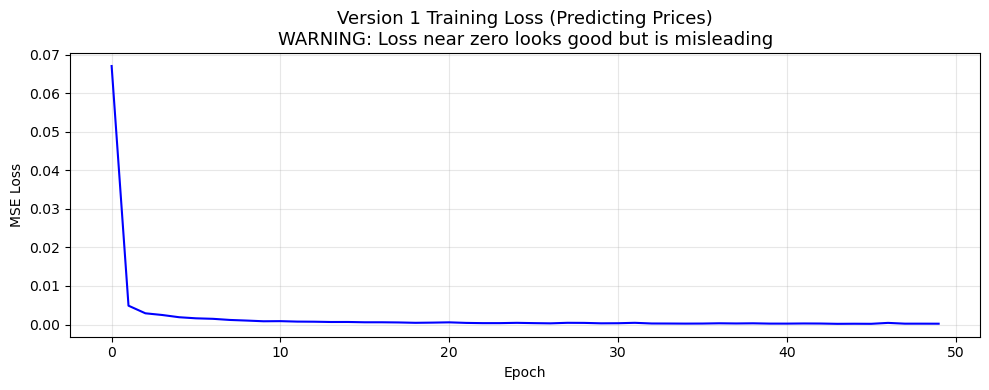

Final training loss: 0.000219
Suspiciously low - this should raise a red flag.


In [15]:
# =============================================================
# FIRST ATTEMPT: Predicting Raw Prices (The Wrong Approach)
#
# Our initial instinct was to predict tomorrow's price directly.
# The model seemed to perform perfectly - loss near zero,
# predictions almost identical to actual prices.
#
# But this was a trap.
# =============================================================

# Train on raw prices instead of returns
prices_scaled = scaler.fit_transform(
    prices.values.reshape(-1, 1)).flatten()

split_idx_v1 = int(len(prices_scaled) * SPLIT)
train_data_v1 = prices_scaled[:split_idx_v1]
test_data_v1 = prices_scaled[split_idx_v1 - SEQ_LEN:]

train_loader_v1 = DataLoader(
    TimeSeriesDataset(train_data_v1, SEQ_LEN, PRED_LEN),
    batch_size=32, shuffle=True)
test_loader_v1 = DataLoader(
    TimeSeriesDataset(test_data_v1, SEQ_LEN, PRED_LEN),
    batch_size=32, shuffle=False)

model_v1 = TransformerModel()
optimizer_v1 = torch.optim.Adam(model_v1.parameters(), lr=0.001)
train_losses_v1 = []

for epoch in range(EPOCHS):
    model_v1.train()
    epoch_loss = 0
    for x_batch, y_batch in train_loader_v1:
        optimizer_v1.zero_grad()
        loss = criterion(model_v1(x_batch), y_batch)
        loss.backward()
        optimizer_v1.step()
        epoch_loss += loss.item()
    train_losses_v1.append(epoch_loss / len(train_loader_v1))

plt.figure(figsize=(10, 4))
plt.plot(train_losses_v1, color='blue')
plt.title('Version 1 Training Loss (Predicting Prices)\n'
          'WARNING: Loss near zero looks good but is misleading',
          fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06a_loss_v1_prices.png', dpi=150)
plt.show()

print(f"Final training loss: {train_losses_v1[-1]:.6f}")
print("Suspiciously low - this should raise a red flag.")

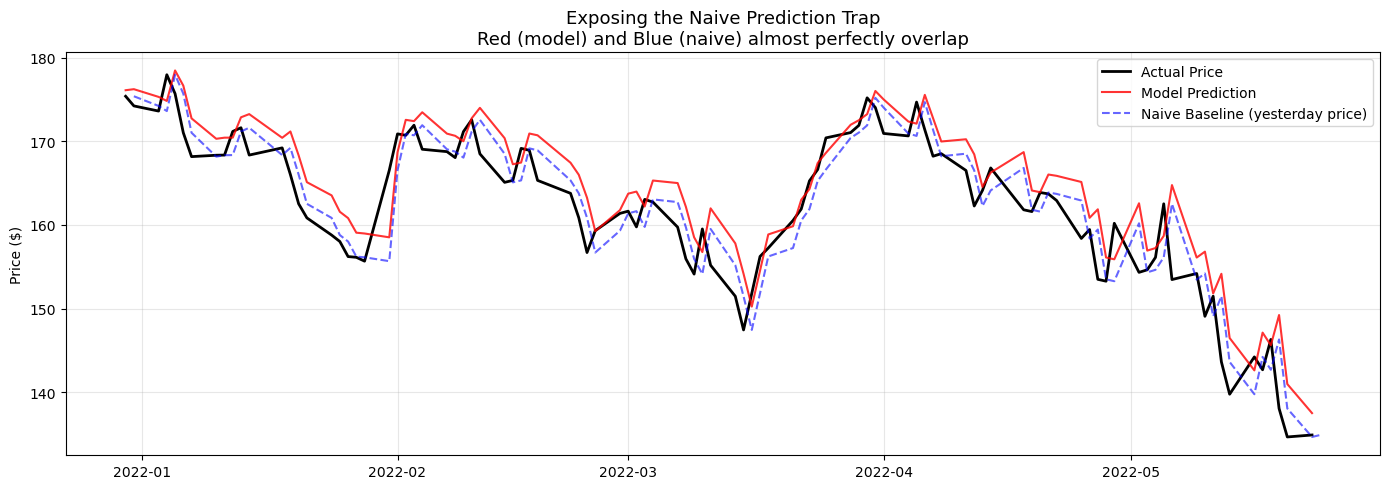

Conclusion: The model is not predicting the future.
It is simply copying the current price as tomorrow's prediction.
This is why raw price prediction is the WRONG task formulation.


In [16]:
# =============================================================
# EXPOSING THE TRAP: The Naive Prediction Problem
#
# If the model is "cheating", its predictions should look
# almost identical to simply shifting the actual price by one day.
#
# We plot three lines:
# - Actual price (black): ground truth
# - Model prediction (red): what our model predicted
# - Naive baseline (blue dashed): just use yesterday's price
#
# If red and blue overlap: the model learned nothing useful.
# It just learned to copy yesterday's price.
#
# This is called the "Naive Prediction Trap" and it is one of
# the most common mistakes in financial deep learning.
# =============================================================

model_v1.eval()
preds_v1 = []
acts_v1 = []

with torch.no_grad():
    for x_batch, y_batch in test_loader_v1:
        pred = model_v1(x_batch)
        preds_v1.extend(pred.numpy().flatten())
        acts_v1.extend(y_batch.numpy().flatten())

preds_v1_real = scaler.inverse_transform(
    np.array(preds_v1).reshape(-1, 1)).flatten()
acts_v1_real = scaler.inverse_transform(
    np.array(acts_v1).reshape(-1, 1)).flatten()

test_dates_v1 = dates[split_idx_v1 + 1:][:len(preds_v1_real)]

# Plot first 100 days for clarity
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates_v1[:100], acts_v1_real[:100],
        label='Actual Price', color='black', linewidth=2)
ax.plot(test_dates_v1[:100], preds_v1_real[:100],
        label='Model Prediction', color='red', alpha=0.8)

# The naive baseline: yesterday's price as tomorrow's prediction
# If model prediction overlaps this line, it learned nothing
ax.plot(test_dates_v1[1:101], acts_v1_real[:100],
        label='Naive Baseline (yesterday price)',
        color='blue', linestyle='--', alpha=0.6)

ax.set_title('Exposing the Naive Prediction Trap\n'
             'Red (model) and Blue (naive) almost perfectly overlap',
             fontsize=13)
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06b_naive_prediction_trap.png', dpi=150)
plt.show()

print("Conclusion: The model is not predicting the future.")
print("It is simply copying the current price as tomorrow's prediction.")
print("This is why raw price prediction is the WRONG task formulation.")

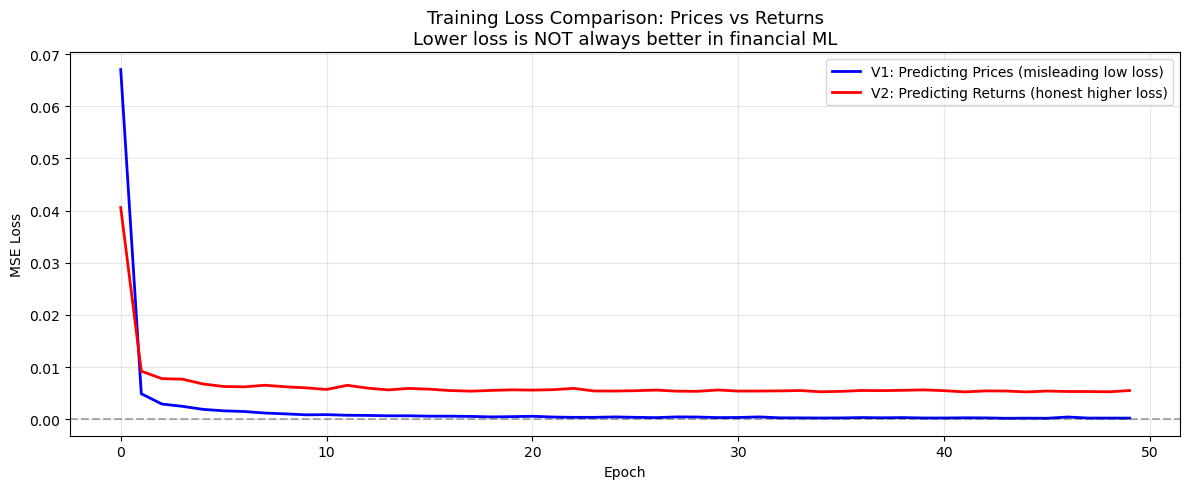

Key insight: In financial ML, a suspiciously low loss
is a warning sign, not a success signal.
Always sanity-check your model against naive baselines.


In [17]:
# =============================================================
# THE FIX: Switch from Prices to Returns
#
# By predicting returns (% change) instead of prices:
# 1. The naive baseline (predicting 0% change every day) is no
#    longer a good strategy - returns are much noisier than prices
# 2. The model is forced to learn genuine directional signals
# 3. Loss stays higher - but this is HONEST, not a failure
#
# Higher loss on a harder task > near-zero loss on a trivial task
#
# This comparison chart shows the difference:
# - Blue: Version 1 (prices) - loss drops to near zero (misleading)
# - Red: Version 2 (returns) - loss stays higher (honest)
# =============================================================

plt.figure(figsize=(12, 5))
plt.plot(train_losses_v1, color='blue', linewidth=2,
         label='V1: Predicting Prices (misleading low loss)')
plt.plot(train_losses, color='red', linewidth=2,
         label='V2: Predicting Returns (honest higher loss)')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.title('Training Loss Comparison: Prices vs Returns\n'
          'Lower loss is NOT always better in financial ML',
          fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06c_loss_comparison.png', dpi=150)
plt.show()

print("Key insight: In financial ML, a suspiciously low loss")
print("is a warning sign, not a success signal.")
print("Always sanity-check your model against naive baselines.")

Epoch 10/50 | Loss: 0.005378
Epoch 20/50 | Loss: 0.005618
Epoch 30/50 | Loss: 0.005527
Epoch 40/50 | Loss: 0.005323
Epoch 50/50 | Loss: 0.005438


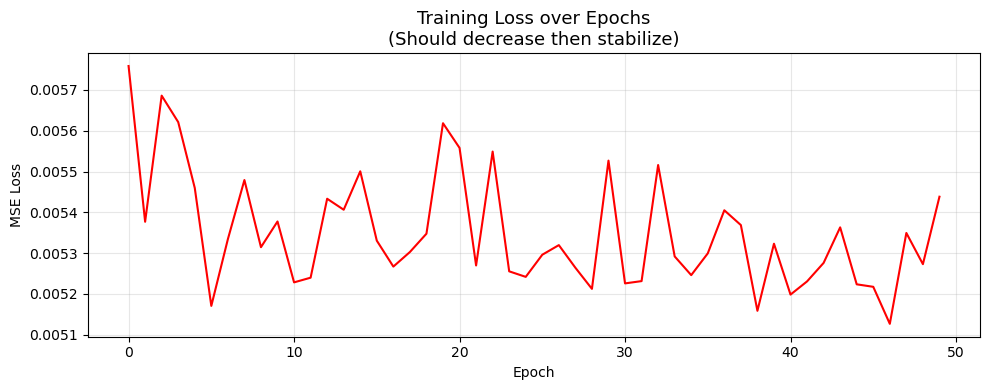

In [18]:
# =============================================================
# TRAINING LOOP
#
# How neural network training works:
# 1. Feed a batch of input sequences through the model
# 2. Compare predictions to actual returns (compute loss)
# 3. Calculate gradients: how should each parameter change
#    to reduce the loss? (backpropagation)
# 4. Update parameters in the direction that reduces loss
#    (gradient descent via Adam optimizer)
# 5. Repeat for all batches = one epoch
# 6. Repeat for all epochs
#
# Loss function: MSE (Mean Squared Error)
# MSE = average of (predicted - actual)^2
# Penalizes large errors more than small ones.
#
# What to watch: loss should decrease over epochs.
# If it stops decreasing, the model has converged.
# If it goes back up on validation data, overfitting is occurring.
# =============================================================

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
EPOCHS = 50
train_losses = []

for epoch in range(EPOCHS):
    model.train()  # enable dropout and batch norm
    epoch_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()        # clear previous gradients
        pred = model(x_batch)        # forward pass
        loss = criterion(pred, y_batch)  # compute loss
        loss.backward()              # backpropagation
        optimizer.step()             # update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

# Training loss curve
# A healthy curve: starts high, decreases, then levels off
# Danger sign: loss near zero = model may be cheating (naive prediction)
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='red')
plt.title('Training Loss over Epochs\n(Should decrease then stabilize)',
          fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/06_training_loss.png', dpi=150)
plt.show()

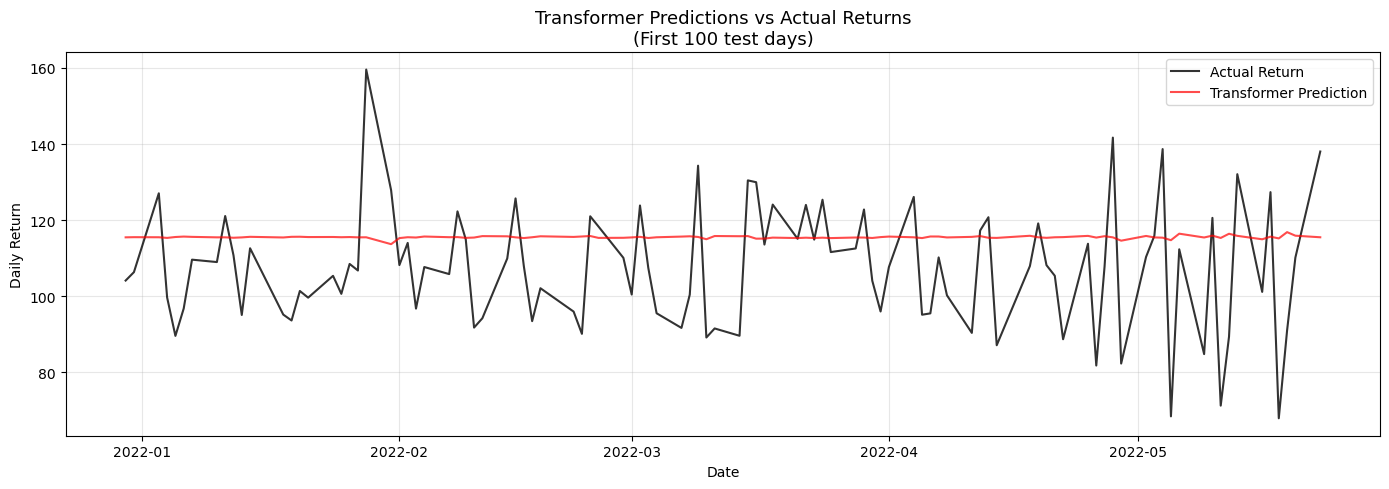

Mean Absolute Error (MAE): 11.2995
(In return space - e.g. 0.01 means average error of 1%)


In [19]:
# =============================================================
# GENERATE PREDICTIONS AND BACKTEST
#
# After training, we run the model on the test set.
# model.eval() disables dropout for stable predictions.
# torch.no_grad() skips gradient computation - we're not
# training anymore, just predicting. This saves memory.
#
# Signal generation logic:
# - If predicted return > 0: model expects price to rise -> buy (1)
# - If predicted return < 0: model expects price to fall -> cash (0)
#
# Note: predictions are in scaled space [0,1]
# We use inverse_transform to convert back to real return values
# before interpreting direction.
# =============================================================

model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        pred = model(x_batch)
        predictions.extend(pred.numpy().flatten())
        actuals.extend(y_batch.numpy().flatten())

# Convert scaled predictions back to real return values
predictions_real = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)).flatten()
actuals_real = scaler.inverse_transform(
    np.array(actuals).reshape(-1, 1)).flatten()

# --- Naive Prediction Check ---
# This chart exposes a common trap: is the model just predicting
# "tomorrow = today"? If prediction line overlaps with the
# "yesterday's price" line, the model learned nothing useful.
test_dates = dates[split_idx + 1:][:len(predictions_real)]

plt.figure(figsize=(14, 5))
plt.plot(test_dates[:100], actuals_real[:100],
         label='Actual Return', color='black', alpha=0.8)
plt.plot(test_dates[:100], predictions_real[:100],
         label='Transformer Prediction', color='red', alpha=0.7)
plt.title('Transformer Predictions vs Actual Returns\n'
          '(First 100 test days)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/07_transformer_prediction.png', dpi=150)
plt.show()

mae = np.mean(np.abs(predictions_real - actuals_real))
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"(In return space - e.g. 0.01 means average error of 1%)")

=== Era 3: Transformer Strategy ===
Total Return (%): 9.28
Annual Return (%): 4.54
Max Drawdown (%): -30.91
Sharpe Ratio: 0.23


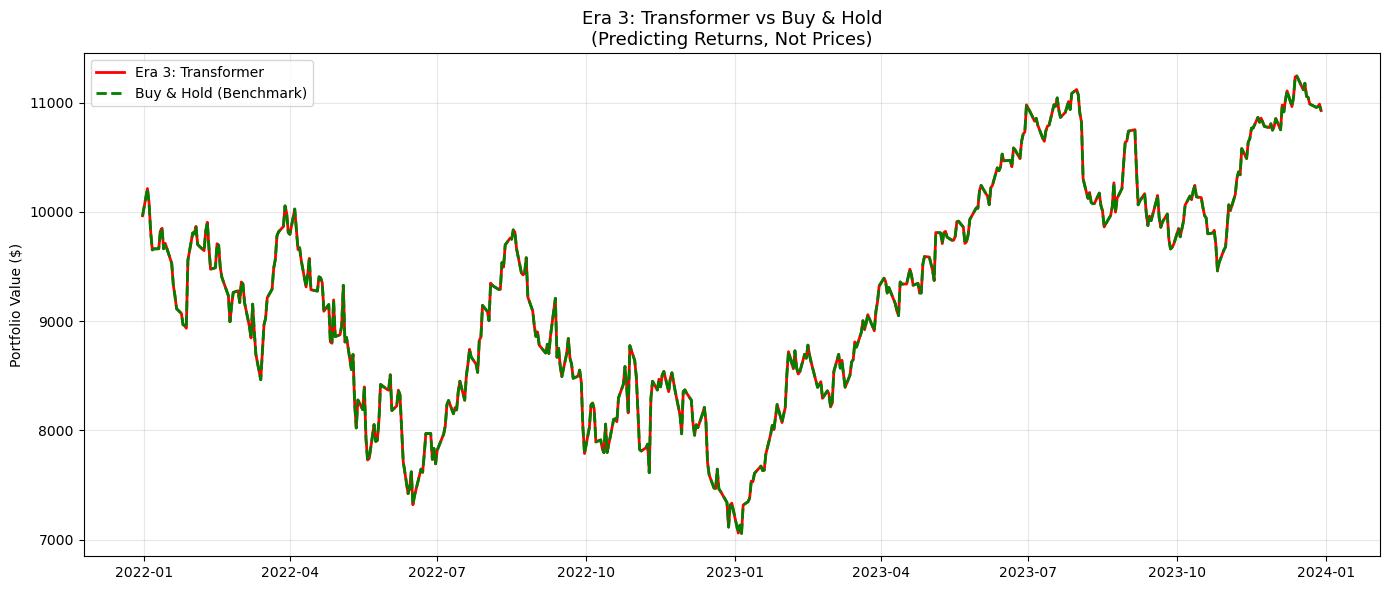

In [20]:
# =============================================================
# BACKTEST: ERA 3 TRANSFORMER
#
# Convert predicted returns into binary trading signals:
# positive predicted return -> hold (1)
# negative predicted return -> cash (0)
#
# This is the honest version of our Transformer strategy.
# Unlike the naive price-prediction version which showed
# near-perfect fit but zero trading value, this version
# tackles the genuinely hard problem of predicting direction.
# =============================================================

def backtest(prices, signal, initial_capital=10000):
    daily_returns = prices.pct_change()
    strategy_returns = signal.shift(1) * daily_returns
    portfolio = initial_capital * (1 + strategy_returns).cumprod()
    buy_and_hold = initial_capital * (1 + daily_returns).cumprod()
    total_return = (portfolio.iloc[-1] / initial_capital - 1) * 100
    n_years = len(prices) / 252
    annual_return = ((portfolio.iloc[-1] / initial_capital) ** (1/n_years) - 1) * 100
    rolling_max = portfolio.cummax()
    max_drawdown = ((portfolio - rolling_max) / rolling_max).min() * 100
    excess_returns = strategy_returns - 0.02/252
    sharpe = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    return {
        'Total Return (%)': round(total_return, 2),
        'Annual Return (%)': round(annual_return, 2),
        'Max Drawdown (%)': round(max_drawdown, 2),
        'Sharpe Ratio': round(sharpe, 2)
    }, portfolio, buy_and_hold

# Generate binary signal from predicted return direction
test_prices = prices[test_dates]
signal_tf = pd.Series(
    (predictions_real > 0).astype(float),
    index=test_dates
)

results_tf, portfolio_tf, bah = backtest(test_prices, signal_tf)

print("=== Era 3: Transformer Strategy ===")
for k, v in results_tf.items():
    print(f"{k}: {v}")

# Final comparison chart
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(portfolio_tf.index, portfolio_tf,
        label='Era 3: Transformer', color='red', linewidth=2)
ax.plot(bah.index, bah,
        label='Buy & Hold (Benchmark)', color='green',
        linestyle='--', linewidth=2)
ax.set_title('Era 3: Transformer vs Buy & Hold\n'
             '(Predicting Returns, Not Prices)', fontsize=13)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/08_era3_performance.png', dpi=150)
plt.show()